In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

In [3]:
img = Image.open("/kaggle/input/datasets/agneaybnair/image/pexels-adi-k-182036-28909955.jpg")
img = img.resize((396, 396))
img = np.array(img)

print(img.shape)

(396, 396, 3)


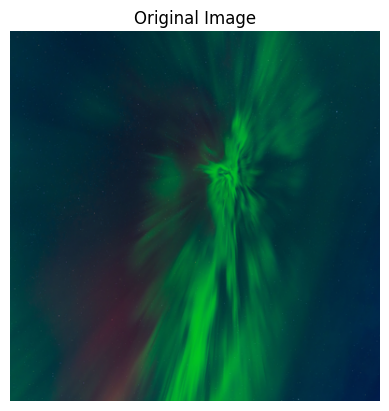

In [4]:
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [5]:
rows, cols, channels = img.shape

pixels = img.reshape(rows * cols, channels)

print(pixels.shape)

(156816, 3)


In [6]:
k = 16

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    init='k-means++'
)

kmeans.fit(pixels)

KMeans(n_clusters=16, random_state=42)

In [8]:
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

compressed_pixels = compressed_pixels.astype(np.uint8)

In [9]:
compressed_img = compressed_pixels.reshape(rows, cols, channels)

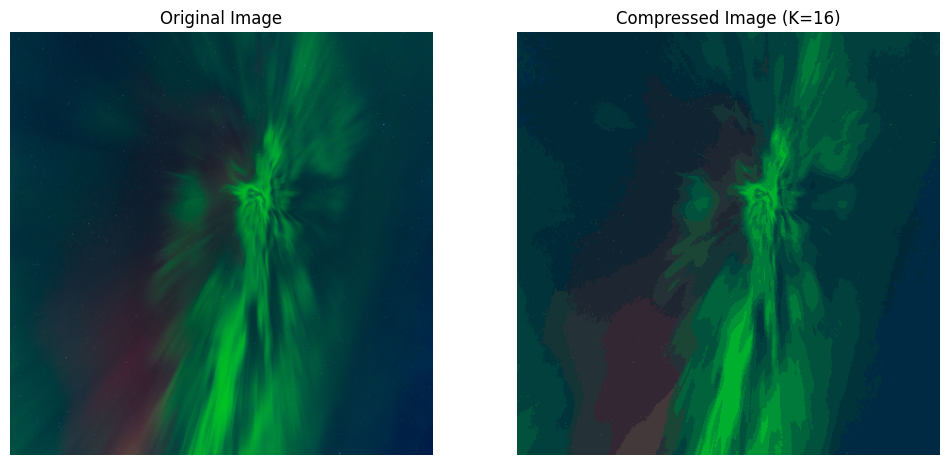

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(compressed_img)
plt.title(f"Compressed Image (K={k})")
plt.axis("off")

plt.show()